In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
sns.set(style='whitegrid', rc={'figure.figsize': (10,5)})

In [2]:
def load_clean(country_name, paths=None):
    """Try common paths for cleaned CSVs and return DataFrame with `country` column."""
    if paths is None:
        paths = [f'../data/{country_name}_clean.csv', f'data/{country_name}_clean.csv']
    for p in paths:
        try:
            df = pd.read_csv(p)
            df = df.copy()
            df['country'] = country_name.split('_')[0].capitalize()
            # ensure Timestamp is datetime if present
            if 'Timestamp' in df.columns:
                df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            return df
        except FileNotFoundError:
            continue
    raise FileNotFoundError(f'No cleaned CSV found for {country_name}; checked: {paths}')

In [3]:
# Load cleaned datasets (adjust filenames if you used different names/paths)
dfs = []
for name in ['benin', 'sierraleone', 'togo']:
    try:
        df = load_clean(name)
        dfs.append(df)
        print('Loaded', name)
    except FileNotFoundError as e:
        print(e)
        # continue so notebook still opens even if a file is missing
if not dfs:
    raise SystemExit('No cleaned files found. Place cleaned CSVs under ../data/ with names <country>_clean.csv')
combined = pd.concat(dfs, ignore_index=True, sort=False)
combined['country'] = combined['country'].astype('category')
display(combined.head())

Loaded benin
Loaded sierraleone
Loaded togo


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,...,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,is_outlier,n_outlier_cols,country
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,...,0.0,998,0,0.0,26.3,26.2,NaN,False,7,Benin
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,...,0.0,998,0,0.0,26.3,26.2,NaN,False,7,Benin
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,...,1.5,997,0,0.0,26.4,26.2,NaN,False,7,Benin
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,...,1.3,997,0,0.0,26.4,26.3,NaN,False,7,Benin
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,...,1.0,997,0,0.0,26.4,26.3,NaN,False,7,Benin


C:\Users\Owner\AppData\Local\Temp\ipykernel_8452\2332627880.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y=m, data=combined, palette='Set2')


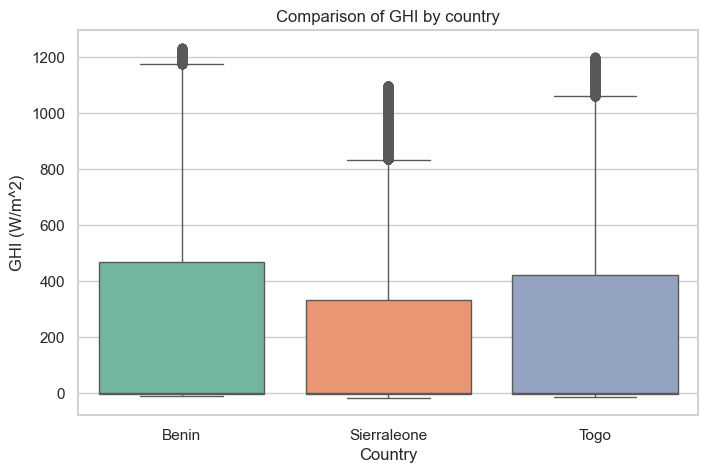

C:\Users\Owner\AppData\Local\Temp\ipykernel_8452\2332627880.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y=m, data=combined, palette='Set2')


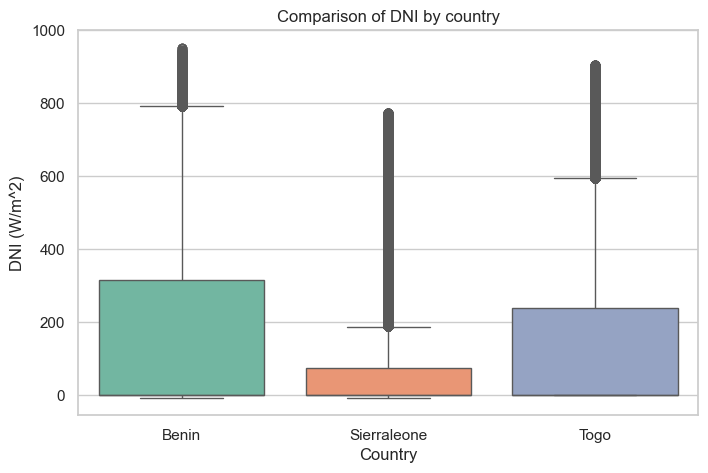

C:\Users\Owner\AppData\Local\Temp\ipykernel_8452\2332627880.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y=m, data=combined, palette='Set2')


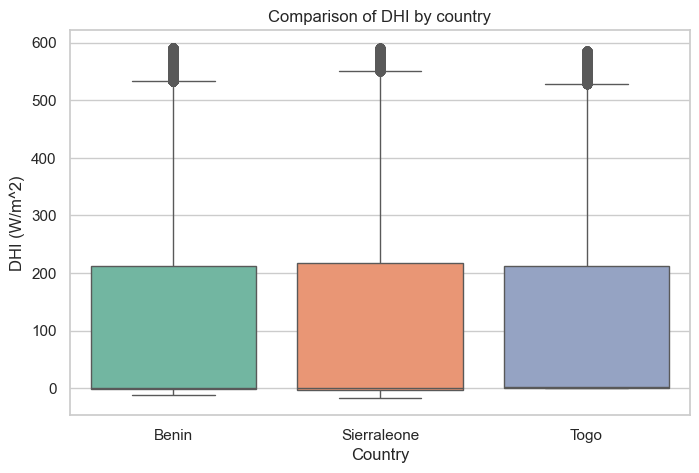

In [4]:
# Metric comparison: boxplots for GHI, DNI, DHI side-by-side
metrics = ['GHI', 'DNI', 'DHI']
for m in metrics:
    if m in combined.columns:
        plt.figure(figsize=(8,5))
        sns.boxplot(x='country', y=m, data=combined, palette='Set2')
        plt.title(f'Comparison of {m} by country')
        plt.ylabel(f'{m} (W/m^2)')
        plt.xlabel('Country')
        plt.show()
    else:
        print(f'{m} not found in combined data')

In [ ]:
# Summary table: mean, median, std for each metric and country
summary = combined.groupby('country')[metrics].agg(['mean','median','std',]).round(2)
# flatten multiindex columns
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
display(summary)
# also save to CSV
summary.to_csv('../data/compare_summary_stats.csv')


,GHI_mean,GHI_median,GHI_std,DNI_mean,DNI_median,DNI_std,DHI_mean,DHI_median,DHI_std
country,,,,,,,,,
Benin,236.23,0.7,328.29,166.90,-0.1,262.08,111.66,0.5,153.10
Sierraleone,185.00,-0.4,279.02,104.13,-0.1,200.95,108.10,-0.6,153.69
Togo,223.86,0.5,317.31,147.98,0.0,247.68,112.78,1.5,151.57


In [8]:
# Statistical testing on GHI values
ghi_groups = [g['GHI'].dropna().values for _, g in combined.groupby('country') if 'GHI' in g.columns]
if len(ghi_groups) < 2:
    raise ValueError('Need at least two country groups with GHI values for statistical testing.')
anova_res = stats.f_oneway(*ghi_groups)
kw_res = stats.kruskal(*ghi_groups)
print(f'ANOVA p-value: {anova_res.pvalue:.6e}')
print(f'Kruskal-Wallis p-value: {kw_res.pvalue:.6e}')

test_results = pd.DataFrame({
    'test': ['ANOVA', 'Kruskal-Wallis'],
    'statistic': [anova_res.statistic, kw_res.statistic],
    'p_value': [anova_res.pvalue, kw_res.pvalue]
})
display(test_results)
test_results.to_csv('../data/compare_ghi_tests.csv', index=False)

ANOVA p-value: 0.000000e+00
Kruskal-Wallis p-value: 0.000000e+00


,test,statistic,p_value
0,ANOVA,3833.184203,0.0
1,Kruskal-Wallis,6548.533789,0.0


## Key Observations
- Benin and Togo appear to have higher typical GHI and DNI values than Sierra Leone, based on the boxplot medians.
- Sierra Leone tends to show lower direct solar radiation and a tighter spread for DNI, suggesting weaker direct sunlight overall.
- DHI looks more similar across the three countries, so the countries are less separated on diffuse irradiance than on GHI or DNI.

,average_GHI
country,
Benin,236.234508
Togo,223.859675
Sierraleone,185.000024


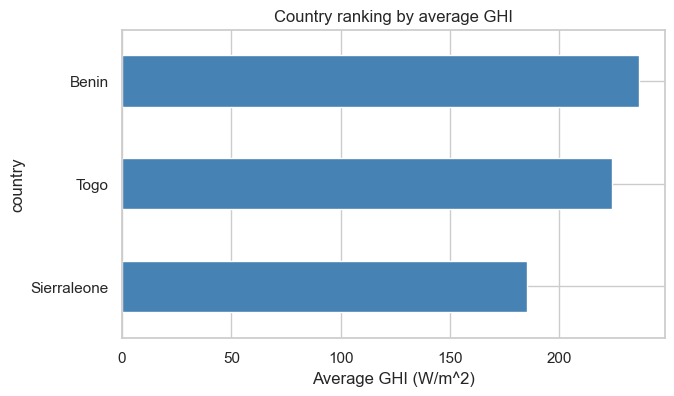

In [7]:
# Bonus: rank countries by average GHI
ghi_ranking = combined.groupby('country')['GHI'].mean().sort_values(ascending=False)
display(ghi_ranking.to_frame(name='average_GHI'))
plt.figure(figsize=(7,4))
ghi_ranking.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Average GHI (W/m^2)')
plt.title('Country ranking by average GHI')
plt.show()